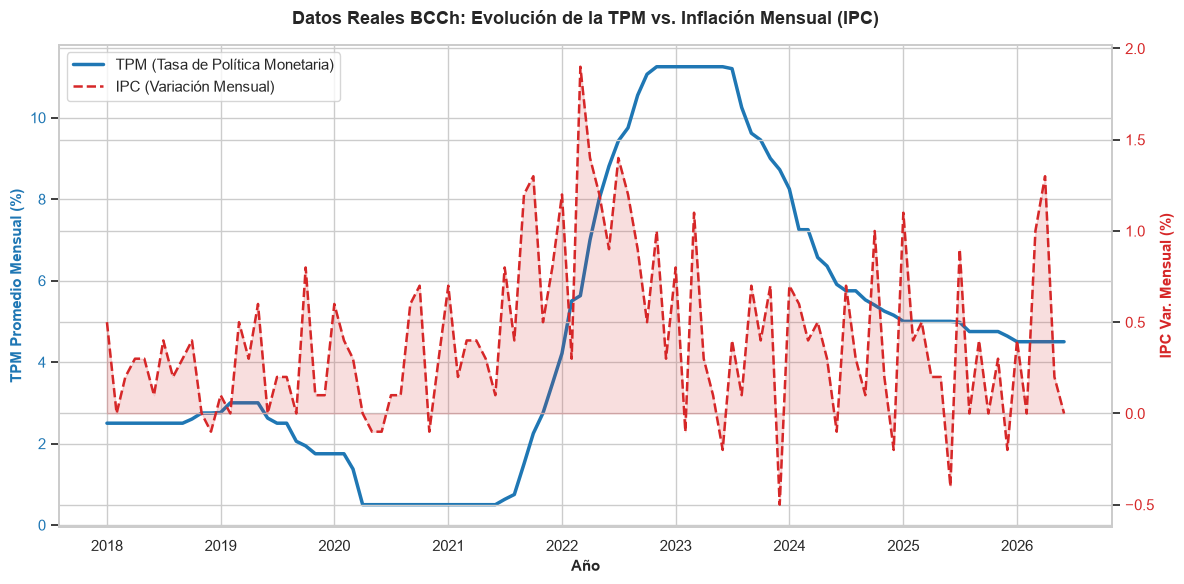

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. LIMPIEZA DE TPM
df_tpm_raw = pd.read_excel("datos_banco_central_TPM.xlsx")
# Traspasamos y seleccionamos ÚNICAMENTE la fila 1 (Fechas) y la fila 2 (Valores)
df_tpm = df_tpm_raw.T.iloc[1:, [1, 2]].reset_index(drop=True)
df_tpm.columns = ["Fecha", "TPM"]
df_tpm["Fecha"] = pd.to_datetime(df_tpm["Fecha"], errors="coerce")
df_tpm["TPM"] = pd.to_numeric(df_tpm["TPM"], errors="coerce")

# 2. LIMPIEZA DE IPC
df_ipc_raw = pd.read_excel("datos_banco_central_IPC.xlsx")
df_ipc = df_ipc_raw.T.iloc[1:, [1, 2]].reset_index(drop=True)
df_ipc.columns = ["Fecha", "IPC_VarMensual"]
df_ipc["Fecha"] = pd.to_datetime(df_ipc["Fecha"], errors="coerce")
df_ipc["IPC_VarMensual"] = pd.to_numeric(
    df_ipc["IPC_VarMensual"], errors="coerce"
)

# 3. CONVERSIÓN MENSUAL Y MERGE
df_tpm_mensual = (
    df_tpm.dropna(subset=["Fecha"])
    .groupby(df_tpm["Fecha"].dt.to_period("M"))["TPM"]
    .mean()
    .reset_index()
)
df_tpm_mensual["Fecha"] = df_tpm_mensual["Fecha"].dt.to_timestamp()

df_ipc = df_ipc.dropna(subset=["Fecha"])

# Unimos ambos datasets
df = pd.merge(df_tpm_mensual, df_ipc, on="Fecha", how="inner")

# Filtramos desde 2018 para mejor visualización
df = df[df["Fecha"] >= "2018-01-01"].sort_values("Fecha").reset_index(drop=True)

# 4. GRÁFICO CON DATOS REALES
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje 1: TPM (Azul)
color_tpm = "#1f77b4"
ax1.set_xlabel("Año", fontsize=11, fontweight="bold")
ax1.set_ylabel(
    "TPM Promedio Mensual (%)", color=color_tpm, fontsize=11, fontweight="bold"
)
line1 = ax1.plot(
    df["Fecha"],
    df["TPM"],
    color=color_tpm,
    linewidth=2.5,
    label="TPM (Tasa de Política Monetaria)",
)
ax1.tick_params(axis="y", labelcolor=color_tpm)

# Eje 2: IPC (Rojo)
ax2 = ax1.twinx()
color_ipc = "#d62728"
ax2.set_ylabel(
    "IPC Var. Mensual (%)", color=color_ipc, fontsize=11, fontweight="bold"
)
line2 = ax2.plot(
    df["Fecha"],
    df["IPC_VarMensual"],
    color=color_ipc,
    linewidth=1.8,
    linestyle="--",
    label="IPC (Variación Mensual)",
)
ax2.fill_between(
    df["Fecha"], df["IPC_VarMensual"], color=color_ipc, alpha=0.15
)
ax2.tick_params(axis="y", labelcolor=color_ipc)

# Unificar leyenda y mostrar
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", frameon=True, facecolor="white")

plt.title(
    "Datos Reales BCCh: Evolución de la TPM vs. Inflación Mensual (IPC)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
fig.tight_layout()

plt.show()

In [9]:
# 5. CÁLCULO DE ESTADÍSTICAS DESCRIPTIVAS
stats_summary = df[['TPM', 'IPC_VarMensual']].describe().round(2)
stats_summary.columns = ['TPM (%)', 'IPC Var. Mensual (%)']

print("====================================================")
print("  RESUMEN ESTADÍSTICO DE LA MUESTRA (2018 - ACT)")
print("====================================================")
print(stats_summary)

# Identificar hitos clave en el dataset
max_tpm_fecha = df.loc[df['TPM'].idxmax(), 'Fecha'].strftime('%B %Y')
max_tpm_val = df['TPM'].max()

max_ipc_fecha = df.loc[df['IPC_VarMensual'].idxmax(), 'Fecha'].strftime('%B %Y')
max_ipc_val = df['IPC_VarMensual'].max()

print(f"\n Máximo histórico TPM: {max_tpm_val}% (Registrado en {max_tpm_fecha})")
print(f" Máximo pico inflacionario IPC: {max_ipc_val}% mensual (Registrado en {max_ipc_fecha})")

  RESUMEN ESTADÍSTICO DE LA MUESTRA (2018 - ACT)
       TPM (%)  IPC Var. Mensual (%)
count   102.00                102.00
mean      4.63                  0.41
std       3.38                  0.44
min       0.50                 -0.50
25%       2.31                  0.10
50%       4.50                  0.30
75%       6.24                  0.70
max      11.25                  1.90

 Máximo histórico TPM: 11.25% (Registrado en November 2022)
 Máximo pico inflacionario IPC: 1.9% mensual (Registrado en March 2022)


## 📝 Conclusiones e Interpretación Macroeconómica

El análisis visual y cuantitativo de las series temporales del Banco Central de Chile entre 2018 y 2026 evidencia la efectividad y el rezago de la Política Monetaria frente a las presiones inflacionarias:

1. **Shock de Inflación Post-Pandemia (2021–2022):**
   A partir de 2021, la variación mensual del IPC experimentó incrementos sostenidos, alcanzando su pico de variación mensual de **1.9% en marzo de 2022**.

2. **Respuesta Contractiva de la Política Monetaria (2022–2023):**
   Como mecanismo de contención, el Banco Central elevó la Tasa de Política Monetaria (TPM) desde niveles mínimos expansivos del **0.5%** hasta un techo histórico del **11.25%** a fines de 2022.

3. **Efecto de Transmisión y Estabilización (2023–2026):**
   El enfriamiento de la demanda interna generado por la alta tasa de interés logró contener la volatilidad del IPC. Con la inflación controlada dentro del rango meta, la autoridad monetaria inició un ciclo de recortes progresivos para llevar la tasa hacia niveles neutrales alrededor del **4.5%**.